## Continuación de la práctica (Puntos 1 a 3)

A partir del documento `M3P1_Metodos_Reduccion.pdf`, en esta sección se completa:

1. EDA breve del conjunto de datos.
2. Selección y justificación de variables relevantes para marginación municipal.
3. Reducción de dimensionalidad a 2 componentes para visualización e interpretación.


In [21]:
import zipfile
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 200)

zip_path = 'data/M3P1_Metodos_Reduccion.zip'
with zipfile.ZipFile(zip_path) as z:
    censo = pd.read_csv(
        z.open('iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv'),
        low_memory=False
    )

# Convertimos columnas numéricas y preservamos nombres geográficos
for col in censo.columns:
    if col not in ['NOM_ENT', 'NOM_MUN', 'NOM_LOC', 'LONGITUD', 'LATITUD']:
        censo[col] = pd.to_numeric(censo[col], errors='coerce')

# Municipio: ENTIDAD > 0, MUN > 0, LOC == 0 (registro agregado municipal)
mun = censo[(censo['ENTIDAD'] > 0) & (censo['MUN'] > 0) & (censo['LOC'] == 0)].copy()



mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'POBTOT', 'TVIVPARHAB']].head()

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT,TVIVPARHAB
6,1,Aguascalientes,1,Aguascalientes,948990,266778.0
574,1,Aguascalientes,2,Asientos,51536,12542.0
749,1,Aguascalientes,3,Calvillo,58250,15546.0
918,1,Aguascalientes,4,Cosío,17000,3937.0
985,1,Aguascalientes,5,Jesús María,129929,33214.0


### Punto 1. EDA breve

En este análisis exploratorio se revisa:

- Tamaño de población municipal (`POBTOT`) y su asimetría.
- Condición laboral y social con variables agregadas (`PEA`, `POCUPADA`, `PSINDER`).
- Calidad de vivienda con acceso a servicios (`VPH_S_ELEC`, `VPH_NODREN`, `VPH_AGUAFV`).
- Datos faltantes en variables clave para asegurar consistencia del análisis.


Resumen estadístico (variables clave):


,count,mean,std,min,25%,50%,75%,max
POBTOT,2469.0,51038.486837,146990.725590,81.0,4489.0,13552.0,35284.0,1922523.0
P_15YMAS,2469.0,38066.162009,113305.338484,70.0,3210.0,9647.0,25047.0,1468256.0
PEA,2469.0,25225.449170,76860.366446,42.0,1660.0,5798.0,15974.0,1051417.0
POCUPADA,2469.0,24755.497772,75406.946744,42.0,1589.0,5681.0,15705.0,1038460.0
PSINDER,2469.0,13365.618874,39601.424975,12.0,829.0,2969.0,9328.0,594796.0
TVIVPARHAB,2469.0,14264.536655,42255.763377,30.0,1228.0,3617.0,9265.0,576708.0
VPH_S_ELEC,2469.0,108.895504,229.542369,0.0,15.0,43.0,111.0,3848.0
VPH_NODREN,2469.0,607.033617,1141.603100,0.0,76.0,230.0,661.0,14704.0
VPH_AGUAFV,2469.0,492.303362,1145.954149,0.0,25.0,116.0,444.0,15707.0
VPH_SINTIC,2469.0,345.431754,645.106596,0.0,54.0,148.0,385.0,15652.0



Porcentaje de datos faltantes por variable (%):


,pct_missing
POBTOT,0.0
P_15YMAS,0.0
PEA,0.0
POCUPADA,0.0
PSINDER,0.0
TVIVPARHAB,0.0
VPH_S_ELEC,0.0
VPH_NODREN,0.0
VPH_AGUAFV,0.0
VPH_SINTIC,0.0


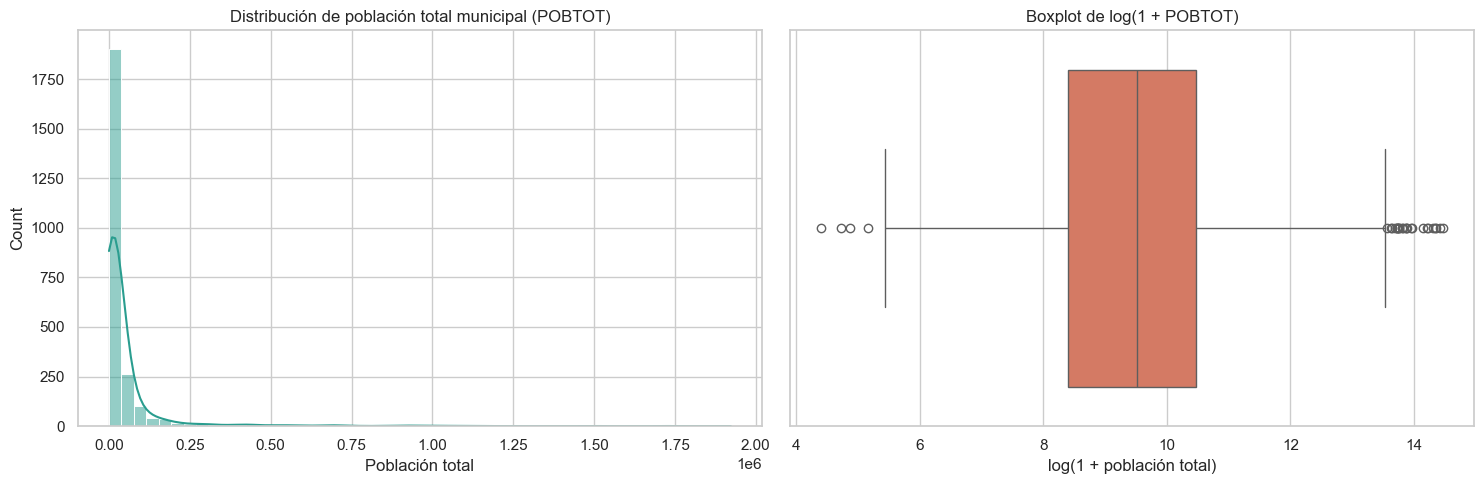

In [22]:
eda_vars = [
    'POBTOT', 'P_15YMAS', 'PEA', 'POCUPADA', 'PSINDER',
    'TVIVPARHAB', 'VPH_S_ELEC', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_SINTIC'
]

eda = mun[eda_vars].copy()

print('Resumen estadístico (variables clave):')
display(eda.describe(percentiles=[0.25, 0.5, 0.75]).T)

missing = eda.isna().mean().sort_values(ascending=False) * 100
print('\nPorcentaje de datos faltantes por variable (%):')
display(missing.to_frame('pct_missing').round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(mun['POBTOT'], bins=50, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribución de población total municipal (POBTOT)')
axes[0].set_xlabel('Población total')

sns.boxplot(x=np.log1p(mun['POBTOT']), ax=axes[1], color='#e76f51')
axes[1].set_title('Boxplot de log(1 + POBTOT)')
axes[1].set_xlabel('log(1 + población total)')

plt.tight_layout()
plt.show()

### EDA: Clasificación del catálogo (sin usar valores de los datos)

Este bloque clasifica el **diccionario/catálogo oficial** por dominio temático y recomendación de uso en el índice.

Enfoque:

- La clasificación se basa en `Indicador`, `Descripción` y `Mnemónico` del diccionario.
- No se usan correlaciones ni distribuciones para decidir utilidad en esta etapa.
- Se marca por variable: `Usar ahora`, `Agregar bloque candidato`, `Agregar como contexto`, `Usar para segmentar` o `No usar en índice`.

Además, se incorpora el catálogo `tam_loc` para proponer estratificación rural/urbana en el EDA.


In [23]:
import re

with zipfile.ZipFile(zip_path) as z:
    dic_raw = pd.read_csv(
        z.open('iter_00_cpv2020/diccionario_datos/diccionario_datos_iter_00CSV20.csv'),
        header=None,
        low_memory=False
    )
    tam_loc = pd.read_csv(z.open('iter_00_cpv2020/catalogos/tam_loc.csv.csv'))

mask = dic_raw[0].astype(str).str.fullmatch(r'\d+', na=False) & dic_raw[3].notna()
catalogo = dic_raw.loc[mask, [1, 2, 3]].copy()
catalogo.columns = ['Indicador', 'Descripcion', 'Mnemónico']
catalogo['Mnemónico'] = catalogo['Mnemónico'].astype(str).str.strip()
catalogo = catalogo.drop_duplicates(subset='Mnemónico').reset_index(drop=True)

vars_geo = {
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN',
    'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC'
}

vars_base_ahora = {
    'P15YM_AN', 'P15YM_SE', 'P6A11_NOA', 'P12A14NOA',
    'PSINDER', 'VPH_PISOTI', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_S_ELEC', 'VPH_SINTIC',
    'P_15YMAS', 'P_6A11', 'P_12A14', 'POBTOT', 'TVIVPARHAB'
}

age_pattern = re.compile(r'^(P_?\d+A\d+|P_?\d+YMAS|P\d+A\d+|POB\d+_\d+)$')


def dominio_catalogo(row):
    var = row['Mnemónico']
    txt = f"{row['Indicador']} {row['Descripcion']}".lower()

    if var in vars_geo:
        return 'Geografía e identificación'

    if 'viviendas particulares habitadas' in txt or var.startswith('VPH_'):
        if any(k in txt for k in ['no disponen de drenaje', 'no disponen de agua entubada', 'no disponen de energía eléctrica', 'piso de tierra']):
            return 'Vivienda y servicios básicos'
        if any(k in txt for k in ['tecnolog', 'internet', 'computadora', 'celular', 'televisión', 'television', 'radio', 'refrigerador', 'lavadora', 'automóvil', 'automovil', 'motocicleta', 'bicicleta']):
            return 'Tecnología y bienes del hogar'
        return 'Condiciones de vivienda'

    if any(k in txt for k in ['analfabeta', 'escolaridad', 'asiste a la escuela', 'primaria', 'secundaria']):
        return 'Educación'

    if any(k in txt for k in ['servicios de salud', 'sin afiliación', 'sin afiliacion', 'afiliada a servicios de salud']):
        return 'Salud y seguridad social'

    if any(k in txt for k in ['económicamente activa', 'economicamente activa', 'ocupada', 'desocupada', 'no económicamente activa', 'no economicamente activa']):
        return 'Actividad económica'

    if any(k in txt for k in ['lengua indígen', 'lengua indig', 'afromexicana', 'afrodescendiente']):
        return 'Población indígena y afrodescendiente'

    if any(k in txt for k in ['discapacidad', 'limitación', 'limitacion']):
        return 'Discapacidad y limitaciones'

    if any(k in txt for k in ['residente en', 'nacida en la entidad', 'nacida en otra entidad']):
        return 'Migración y movilidad'

    if any(k in txt for k in ['católica', 'catolica', 'religión', 'religion', 'estado conyugal', 'hijas e hijos nacidos vivos']):
        return 'Estructura sociodemográfica'

    if var in {'POBTOT', 'POBFEM', 'POBMAS'} or age_pattern.match(var) or var.startswith('P_'):
        return 'Demografía y estructura por edad'

    if any(k in txt for k in ['hogares', 'jefatura', 'hogar']):
        return 'Hogares'

    return 'Otros'


def recomendar_uso(row):
    var = row['Mnemónico']
    dom = row['Dominio']
    is_sexo = var.endswith('_F') or var.endswith('_M')

    if var in vars_base_ahora:
        return ('Usar ahora', 'Variable base directa (numerador/denominador) para construir proporciones comparables.')

    if dom == 'Geografía e identificación':
        return ('No usar en índice', 'Es llave geográfica o referencia espacial; útil para unir/ubicar, no para medir carencia.')

    if dom == 'Demografía y estructura por edad':
        if is_sexo:
            return ('Agregar en análisis específico', 'Desagregación útil para enfoque de edad/sexo, no para el índice base de carencias.')
        return ('Usar para segmentar', 'Aporta composición poblacional para estratificar resultados, no privación directa.')

    if dom in ['Educación', 'Salud y seguridad social', 'Vivienda y servicios básicos']:
        if is_sexo:
            return ('Agregar en análisis específico', 'Indicador relevante, pero su versión por sexo se usa si el objetivo incluye brecha de género.')
        return ('Agregar bloque candidato', 'Dominio estructural de marginación; candidato natural para ampliar el índice.')

    if dom == 'Tecnología y bienes del hogar':
        if var == 'VPH_SINTIC':
            return ('Usar ahora', 'Carencia digital directa incluida en el modelo base.')
        return ('Agregar como contexto', 'Útil para brecha digital/equipamiento; puede complementar, no sustituir carencias básicas.')

    if dom in ['Actividad económica', 'Discapacidad y limitaciones', 'Población indígena y afrodescendiente', 'Migración y movilidad', 'Hogares']:
        return ('Agregar como contexto', 'Puede explicar heterogeneidad territorial; recomendable para extensión del modelo.')

    if dom == 'Estructura sociodemográfica':
        return ('No usar en índice', 'Describe perfil social/cultural; no mide privación material directa en este alcance.')

    return ('Revisar manualmente', 'Sin clasificación robusta automática; requiere revisión de negocio.')


catalogo['Dominio'] = catalogo.apply(dominio_catalogo, axis=1)
catalogo[['Recomendación', 'Justificación']] = catalogo.apply(
    lambda r: pd.Series(recomendar_uso(r)), axis=1
)

print(f'Variables únicas en catálogo: {catalogo.shape[0]:,}')

print('\nResumen por dominio:')
display(catalogo.groupby('Dominio').size().sort_values(ascending=False).rename('n').to_frame())

print('\nResumen por recomendación:')
display(catalogo.groupby('Recomendación').size().sort_values(ascending=False).rename('n').to_frame())

catalogo_clasificado = catalogo[[
    'Mnemónico', 'Indicador', 'Dominio', 'Recomendación', 'Justificación'
]].sort_values(['Recomendación', 'Dominio', 'Mnemónico']).reset_index(drop=True)

print('\nCatálogo clasificado (variable por variable):')
display(catalogo_clasificado)

# Integración del catálogo TAMLOC como estratificador del EDA
tam_loc = tam_loc.copy()

def grupo_tam_loc(code):
    if code <= 4:
        return 'Rural (1 a 2,499 hab)'
    if code <= 8:
        return 'Transición (2,500 a 29,999 hab)'
    return 'Urbano (30,000+ hab)'

tam_loc['grupo_analitico'] = tam_loc['tam_loc'].apply(grupo_tam_loc)

print('\nCatálogo TAMLOC con grupo analítico sugerido:')
display(tam_loc)

# Exportables para trazabilidad del EDA
data_catalogo_out = 'data/eda_catalogo_clasificado.csv'
data_tamloc_out = 'data/eda_catalogo_tamloc_clasificado.csv'
catalogo_clasificado.to_csv(data_catalogo_out, index=False)
tam_loc.to_csv(data_tamloc_out, index=False)

print(f'\nArchivos generados: {data_catalogo_out} y {data_tamloc_out}')


Variables del diccionario: 286
Variables presentes en mun: 286 de 286 columnas en mun

Resumen de decisiones:


,n
Decision,
Descartar,271
Conservar,15



Listado completo (una por una) de variables en mun con decisión y motivo:


,Mnemónico,Indicador,Decision,Grupo,Motivo
0,POBTOT,Población total,Conservar,Denominador,Permite normalizar por población/vivienda y co...
1,P_12A14,Población de 12 a 14 años,Conservar,Denominador,Permite normalizar por población/vivienda y co...
2,P_15YMAS,Población de 15 años y más,Conservar,Denominador,Permite normalizar por población/vivienda y co...
3,P_6A11,Población de 6 a 11 años,Conservar,Denominador,Permite normalizar por población/vivienda y co...
4,TVIVPARHAB,Total de viviendas particulares habitadas,Conservar,Denominador,Permite normalizar por población/vivienda y co...
5,P12A14NOA,Población de 12 a 14 años que no asiste a la e...,Conservar,Numerador,Mide carencia directamente y alimenta variable...
6,P15YM_AN,Población de 15 años y más analfabeta,Conservar,Numerador,Mide carencia directamente y alimenta variable...
7,P15YM_SE,Población de 15 años y más sin escolaridad,Conservar,Numerador,Mide carencia directamente y alimenta variable...
8,P6A11_NOA,Población de 6 a 11 años que no asiste a la es...,Conservar,Numerador,Mide carencia directamente y alimenta variable...
9,PSINDER,Población sin afiliación a servicios de salud,Conservar,Numerador,Mide carencia directamente y alimenta variable...



Correlación de variables por edad con POBTOT (top 10):


,corr_con_POBTOT
P_3YMAS,1.000
P_5YMAS,1.000
POB15_64,1.000
P_12YMAS,0.999
P_18YMAS,0.999
P_40A44,0.998
P_20A24,0.998
P_18A24,0.998
P_25A29,0.997
P_30A34,0.997


Correlación absoluta media entre variables por edad: 0.970

Archivo generado: data/eda_cribado_variables_municipio.csv


### Cómo usar esta clasificación en la práctica

- **Punto 1 (EDA):** usar `tam_loc` como estratificador (rural/transición/urbano) y revisar distribuciones por dominio.
- **Punto 2 (selección):** tomar como núcleo las variables en `Usar ahora` y priorizar `Agregar bloque candidato` para una v2 del índice.
- **Punto 3 (reducción):** mantener el set base para una proyección interpretable; después probar una versión extendida por dominios.

Con esto, la selección deja de ser "básica": queda apoyada en una taxonomía del catálogo oficial y una ruta explícita de expansión del modelo.


### Hallazgos clave del Punto 1

- La distribución de `POBTOT` es altamente asimétrica: pocos municipios concentran mucha población.
- Existe heterogeneidad marcada entre municipios en condiciones de vivienda y acceso a servicios.
- El conjunto municipal es utilizable para modelado al tener bajo porcentaje de faltantes en variables principales.


### Punto 2. Variables seleccionadas para marginación y justificación

Se seleccionan indicadores en **porcentaje** para hacer comparables municipios de distinto tamaño.

Bloques conceptuales:

- **Rezago educativo**: analfabetismo y baja escolaridad.
- **Inasistencia escolar**: población infantil/adolescente fuera de la escuela.
- **Acceso a salud/seguridad social**: población sin derechohabiencia.
- **Carencias de vivienda y servicios básicos**: piso de tierra, sin drenaje, sin agua entubada, sin electricidad.
- **Brecha digital**: viviendas sin TIC.


Municipios con información completa en variables seleccionadas: 2,469


,mean,std,min,50%,max
pct_analfabetismo_15ymas,10.16,7.63,0.35,8.19,53.06
pct_sin_escolaridad_15ymas,9.48,6.70,0.52,7.85,49.88
pct_no_asiste_6a11,4.07,2.70,0.00,3.64,37.31
pct_no_asiste_12a14,10.83,6.47,0.00,9.45,57.86
pct_sin_derechohab,24.13,10.82,1.04,22.63,83.86
pct_piso_tierra,7.98,8.82,0.00,4.76,66.98
pct_sin_drenaje,13.81,19.23,0.00,5.96,99.10
pct_sin_agua_entubada,6.24,9.09,0.00,2.71,78.85
pct_sin_electricidad,1.84,2.81,0.00,1.18,49.42
pct_sin_tic,7.24,8.79,0.00,3.92,60.66


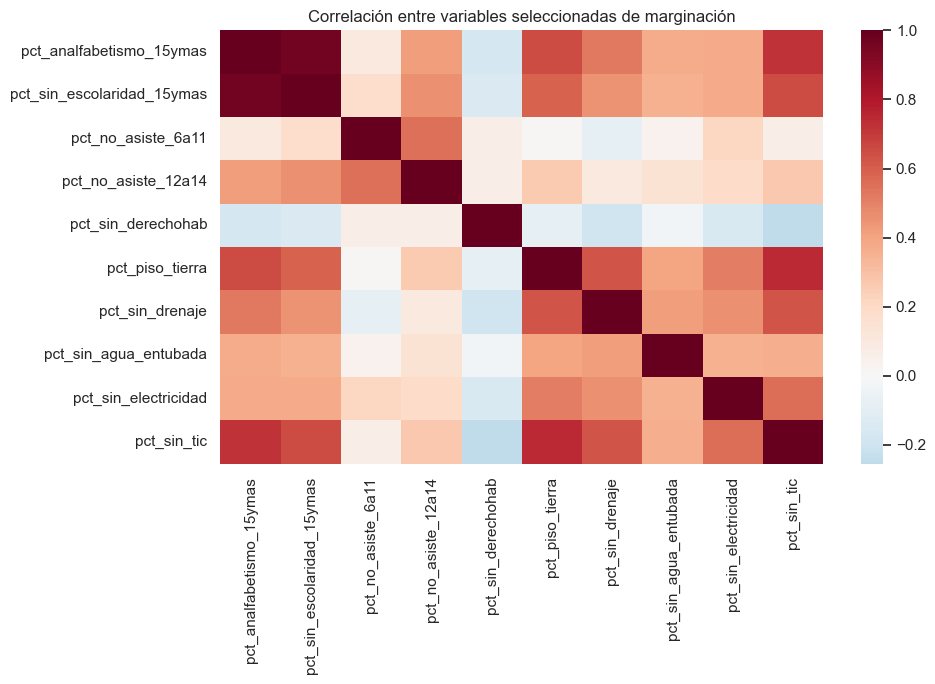

Top 10 municipios con mayor porcentaje de viviendas sin TIC:


,NOM_ENT,NOM_MUN,pct_sin_tic
74601,Guerrero,Cochoapa el Grande,60.66
114707,Oaxaca,Coicoyán de las Flores,58.86
26964,Chiapas,Mitontic,58.63
41015,Chihuahua,Batopilas de Manuel Gómez Morín,57.92
119342,Oaxaca,San Lucas Camotlán,57.36
74413,Guerrero,Acatepec,55.20
119101,Oaxaca,San Juan Petlapa,53.35
123721,Oaxaca,Santiago Apoala,52.32
123670,Oaxaca,Santiago Amoltepec,51.87
55115,Durango,Mezquital,51.81


In [24]:
analisis_mun = mun.copy()

# Construcción de proporciones (%): evita sesgo por tamaño del municipio
analisis_mun['pct_analfabetismo_15ymas'] = 100 * analisis_mun['P15YM_AN'] / analisis_mun['P_15YMAS']
analisis_mun['pct_sin_escolaridad_15ymas'] = 100 * analisis_mun['P15YM_SE'] / analisis_mun['P_15YMAS']
analisis_mun['pct_no_asiste_6a11'] = 100 * analisis_mun['P6A11_NOA'] / analisis_mun['P_6A11']
analisis_mun['pct_no_asiste_12a14'] = 100 * analisis_mun['P12A14NOA'] / analisis_mun['P_12A14']
analisis_mun['pct_sin_derechohab'] = 100 * analisis_mun['PSINDER'] / analisis_mun['POBTOT']
analisis_mun['pct_piso_tierra'] = 100 * analisis_mun['VPH_PISOTI'] / analisis_mun['TVIVPARHAB']
analisis_mun['pct_sin_drenaje'] = 100 * analisis_mun['VPH_NODREN'] / analisis_mun['TVIVPARHAB']
analisis_mun['pct_sin_agua_entubada'] = 100 * analisis_mun['VPH_AGUAFV'] / analisis_mun['TVIVPARHAB']
analisis_mun['pct_sin_electricidad'] = 100 * analisis_mun['VPH_S_ELEC'] / analisis_mun['TVIVPARHAB']
analisis_mun['pct_sin_tic'] = 100 * analisis_mun['VPH_SINTIC'] / analisis_mun['TVIVPARHAB']

vars_marginacion = [
    'pct_analfabetismo_15ymas',
    'pct_sin_escolaridad_15ymas',
    'pct_no_asiste_6a11',
    'pct_no_asiste_12a14',
    'pct_sin_derechohab',
    'pct_piso_tierra',
    'pct_sin_drenaje',
    'pct_sin_agua_entubada',
    'pct_sin_electricidad',
    'pct_sin_tic'
]

modelo_df = analisis_mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'] + vars_marginacion].replace([np.inf, -np.inf], np.nan).dropna().copy()

print(f'Municipios con información completa en variables seleccionadas: {modelo_df.shape[0]:,}')

display(modelo_df[vars_marginacion].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

plt.figure(figsize=(10, 7))
corr = modelo_df[vars_marginacion].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlación entre variables seleccionadas de marginación')
plt.tight_layout()
plt.show()

top_sin_tic = modelo_df.sort_values('pct_sin_tic', ascending=False)[['NOM_ENT', 'NOM_MUN', 'pct_sin_tic']].head(10)
print('Top 10 municipios con mayor porcentaje de viviendas sin TIC:')
display(top_sin_tic.round(2))

### Hallazgos clave del Punto 2

- Las variables de rezago educativo y carencias de vivienda muestran correlaciones positivas, lo cual respalda su uso conjunto para estudiar marginación.
- `pct_sin_derechohab` y `pct_sin_drenaje` tienen promedios altos en términos relativos, señalando brechas estructurales relevantes.
- Los municipios con mayor `pct_sin_tic` se concentran en entidades con rezagos históricos, útil para focalización territorial.


### Punto 3. Reducción de dimensionalidad a 2 dimensiones

Se aplican dos enfoques de proyección:

- **PCA**: técnica lineal para capturar máxima varianza en componentes ortogonales.
- **t-SNE**: técnica no lineal para visualizar estructura local y posibles grupos.

Ambas visualizaciones apoyan la interpretación de patrones de marginación entre municipios.


Varianza explicada por PC1: 0.4467
Varianza explicada por PC2: 0.1586
Varianza explicada acumulada (2 componentes): 0.6054


,PC1,PC2
pct_analfabetismo_15ymas,0.417,0.049
pct_sin_tic,0.411,-0.119
pct_sin_escolaridad_15ymas,0.401,0.132
pct_piso_tierra,0.390,-0.124
pct_sin_drenaje,0.342,-0.287
pct_sin_electricidad,0.307,-0.027
pct_sin_agua_entubada,0.258,-0.094
pct_no_asiste_12a14,0.215,0.594
pct_sin_derechohab,-0.107,0.284
pct_no_asiste_6a11,0.088,0.652


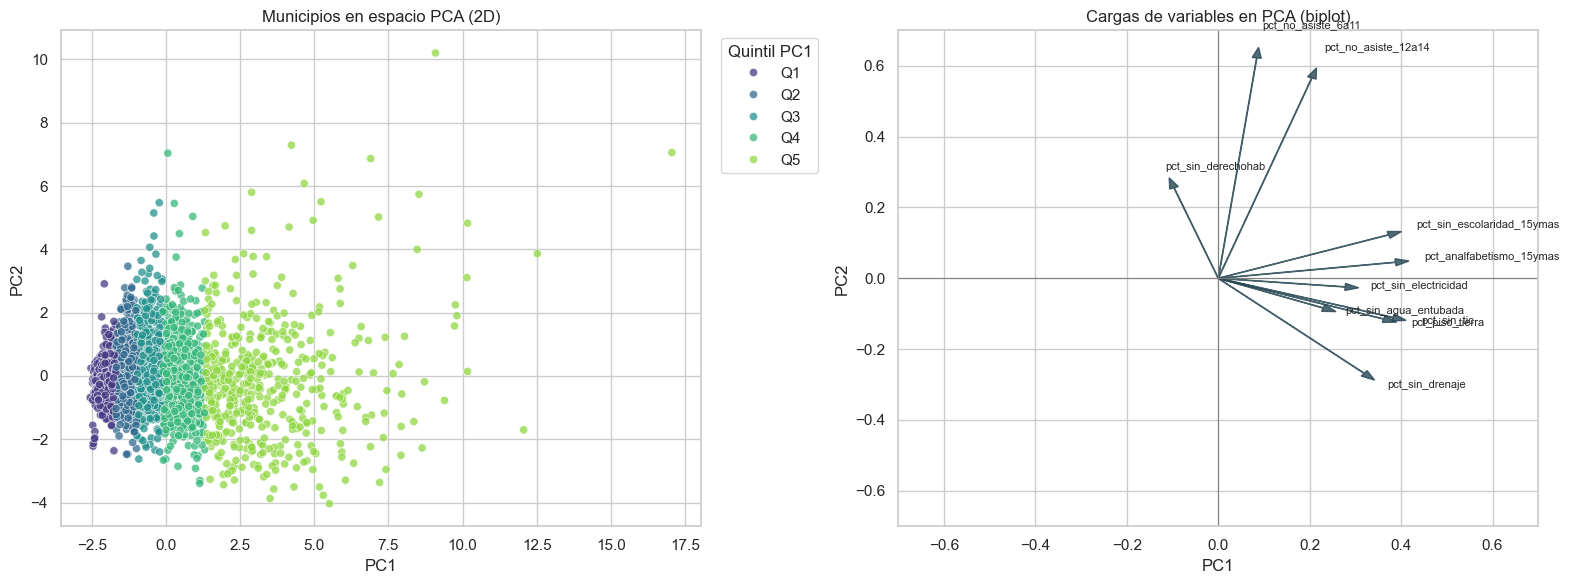

In [25]:
X = modelo_df[vars_marginacion].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=333)
X_pca = pca.fit_transform(X_scaled)

pca_df = modelo_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]
pca_df['quintil_pc1'] = pd.qcut(pca_df['PC1'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_exp[0]:.4f}')
print(f'Varianza explicada por PC2: {var_exp[1]:.4f}')
print(f'Varianza explicada acumulada (2 componentes): {var_exp.sum():.4f}')

loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_marginacion,
    columns=['PC1', 'PC2']
)

display(loadings.sort_values('PC1', key=np.abs, ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35,
    ax=axes[0]
)
axes[0].set_title('Municipios en espacio PCA (2D)')
axes[0].legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')

# Biplot simplificado: direcciones de mayor contribución
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axvline(0, color='gray', lw=0.8)
for var in vars_marginacion:
    x = loadings.loc[var, 'PC1']
    y = loadings.loc[var, 'PC2']
    axes[1].arrow(0, 0, x, y, color='#264653', alpha=0.8, head_width=0.02, length_includes_head=True)
    axes[1].text(x * 1.08, y * 1.08, var, fontsize=8)

axes[1].set_xlim(-0.7, 0.7)
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_title('Cargas de variables en PCA (biplot)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

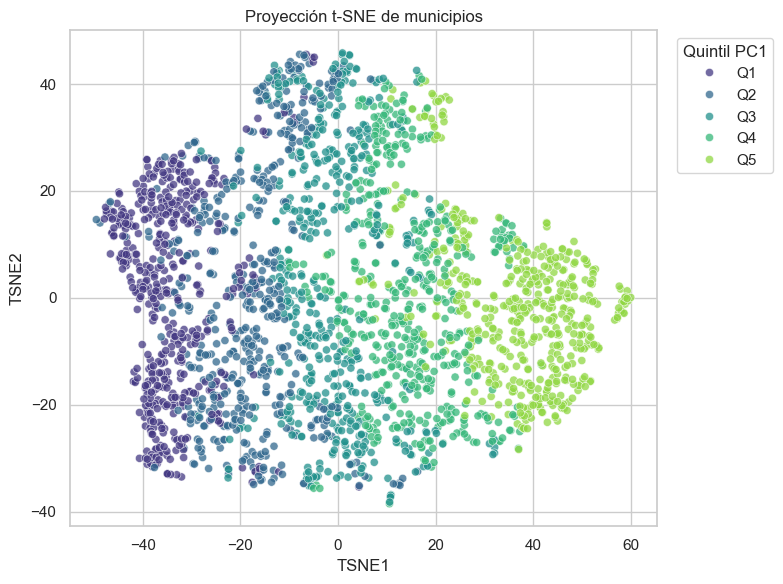

In [26]:
# t-SNE para visualizar estructura no lineal (solo con variables estandarizadas)
tsne = TSNE(
    n_components=2,
    random_state=42,
    init='pca',
    learning_rate='auto',
    perplexity=35
)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = modelo_df[['NOM_ENT', 'NOM_MUN']].copy()
tsne_df['TSNE1'] = X_tsne[:, 0]
tsne_df['TSNE2'] = X_tsne[:, 1]
tsne_df['quintil_pc1'] = pca_df['quintil_pc1'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35
)
plt.title('Proyección t-SNE de municipios')
plt.legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hallazgos clave del Punto 3

- Con 2 componentes, PCA conserva una fracción sustancial de la variabilidad total y permite ordenar municipios en un gradiente interpretable.
- Las mayores cargas en **PC1** suelen corresponder a rezago educativo y carencias de vivienda, por lo que PC1 funciona como eje sintético de marginación estructural.
- t-SNE revela vecindades de municipios con perfiles socioeconómicos similares, útil para segmentación y análisis comparativo.

> Nota: aquí se cumple hasta el **punto 3** de la práctica, dejando fuera la construcción formal del índice final (punto 4).
